In [115]:
def parse_fasta(filepath):
    sequence=[]
    current_seq=''
    with open(filepath,'r') as f:
        for line in f:
            line=line.strip()
            if line.startswith('>'):
                if current_seq:
                    sequence.append(current_seq)
                current_seq=''
            else:
                current_seq+=line
        if current_seq:   
          sequence.append(current_seq)

    return sequence

sequences=parse_fasta(r'C:\Users\LENOVO\Documents\promoter project\FASTA.txt')


In [116]:
def parse_label(filepath):
    label=[]
    with open(filepath, 'r') as f:
        for line in f:
            line=line.strip()
            if line:
                label.append(int(line))

    return label

labels= parse_label(r'C:\Users\LENOVO\Documents\promoter project\Label.txt')    

In [117]:
print(len(sequences))
print(len(labels))

2141
2141


In [118]:
import pandas as pd
df=pd.DataFrame({
    'sequence': sequences,
    'label':labels})
df['label'].value_counts()


label
0    1400
1     741
Name: count, dtype: int64

In [119]:
df_clean = df.copy()
df_clean.to_csv("promoter_dataset_clean.csv", index=False)
print("Saved successfully")
print(df_clean['label'].value_counts())

Saved successfully
label
0    1400
1     741
Name: count, dtype: int64


In [120]:
import pandas as pd
df=pd.read_csv("promoter_dataset_clean.csv")
df.head()


,sequence,label
0,AGCCAGGCGAGATATGATCTATATCAATTTCTCATCTATAATGCTT...,1
1,CGGGCCTATAAGCCAGGCGAGATATGATCTATATCAATTTCTCATC...,1
2,TAAAATCAAATAGCCTACGCAATGTAGGCTTAATGATTAGTCTGAG...,1
3,TTCCTCAACATCATCCTCGCACCAGTCGACGACGGTTTACGCTTTA...,1
4,TCGATTGAGCCTTCCAGTCCTTCGGGACTGGAATTTTTTTGTTCGG...,1


# kmer functions

In [121]:

def get_kmers(sequence,k):
    return [sequence[i:i+k] for i in range(len(sequence)-k+1)] 
import  itertools
def get_all_kmers(k):
    return [''.join(p) for p in itertools.product('ATGC',repeat=k)]
from collections import Counter
def vector(sequence,k):
    kmer= get_kmers(sequence,k)
    count=Counter(kmer)
    return [count[kmers] for kmers in get_all_kmers(k)]    

x2= df['sequence'].apply(lambda x: vector(x,2))
x2=pd.DataFrame(x2.tolist(),columns=get_all_kmers(2))
x2.head()

x3= df['sequence'].apply(lambda x: vector(x,3))
x3=pd.DataFrame(x3.tolist(),columns=get_all_kmers(3))
x3.head()

x4= df['sequence'].apply(lambda x: vector(x,4))
x4=pd.DataFrame(x4.tolist(),columns=get_all_kmers(4))
x4.head()
x4.value_counts()
x3.value_counts()

AAA  AAT  AAG  AAC  ATA  ATT  ATG  ATC  AGA  AGT  AGG  AGC  ACA  ACT  ACG  ACC  TAA  TAT  TAG  TAC  TTA  TTT  TTG  TTC  TGA  TGT  TGG  TGC  TCA  TCT  TCG  TCC  GAA  GAT  GAG  GAC  GTA  GTT  GTG  GTC  GGA  GGT  GGG  GGC  GCA  GCT  GCG  GCC  CAA  CAT  CAG  CAC  CTA  CTT  CTG  CTC  CGA  CGT  CGG  CGC  CCA  CCT  CCG  CCC
2    2    0    1    2    0    1    2    0    2    0    1    2    0    3    0    1    0    0    2    0    0    0    0    1    0    2    1    1    1    4    0    2    1    0    2    0    0    2    3    3    0    5    2    2    1    3    1    0    2    3    0    1    0    1    1    1    3    3    4    0    1    1    0      5
0    1    2    0    2    0    1    0    0    0    1    4    1    0    2    0    1    1    0    1    0    0    0    0    0    2    3    2    2    0    0    1    0    1    0    1    1    0    5    2    2    3    1    3    3    2    5    2    1    0    3    1    0    0    1    1    0    3    4    3    0    0    3    1      4
               2    0    2    0  

In [122]:
y=df['label']
y.value_counts()

label
0    1400
1     741
Name: count, dtype: int64

# training LR

In [123]:
#splitting data 
import sklearn
print(sklearn.__version__)
from sklearn.model_selection import train_test_split
#spliiting the data bc 80% of the data will be used for training and rest for testing
# split y once
_, _, y_train, y_test = train_test_split(x3, y, test_size=0.2, random_state=42)

# split each X separately
x2_train, x2_test, _, _ = train_test_split(x2, y, test_size=0.2, random_state=42)
x3_train, x3_test, _, _ = train_test_split(x3, y, test_size=0.2, random_state=42)
x4_train, x4_test, _, _ = train_test_split(x4, y, test_size=0.2, random_state=42)




#models:
from sklearn.linear_model import LogisticRegression

model_lr3 = LogisticRegression(max_iter=1000,random_state=42,
        class_weight='balanced')
model_lr3.fit(x3_train, y_train)
y3_pred_lr = model_lr3.predict(x3_test)

#for kmer length 2
model_lr2 = LogisticRegression(max_iter=1000,random_state=42,
        class_weight='balanced')
model_lr2.fit(x2_train, y_train)
y2_pred_lr = model_lr2.predict(x2_test)

#for kmer length 4
model_lr4 = LogisticRegression(max_iter=1000,random_state=42,
        class_weight='balanced')
model_lr4.fit(x4_train, y_train)
y4_pred_lr = model_lr4.predict(x4_test)


1.5.1


# accuracy

In [124]:
#2
from sklearn.metrics import accuracy_score, classification_report
test2_acc=accuracy_score(y_test, y2_pred_lr)
train2_acc= accuracy_score(y_train, model_lr2.predict(x2_train))
print('test and trainig accuracy for kmer 2:')
print('test2_acc:',test2_acc, '\ntrain2_acc:',train2_acc)
print('\nclassification report for kmer 2:')
print(classification_report(y_test, y2_pred_lr))
#3

test3_acc=accuracy_score(y_test, y3_pred_lr)
train3_acc= accuracy_score(y_train, model_lr3.predict(x3_train))
print('test and trainig accuracy for kmer 3:')
print('test3_acc:',test3_acc, '\ntrain3_acc:',train3_acc)# here train_acc>test_acc which is overfitting even when kmer length is small bc my dataset is really smallso model memorires instead of generalizing
print('\nclassification report for kmer 3:')
print(classification_report(y_test, y3_pred_lr))

#4
test4_acc=accuracy_score(y_test, y4_pred_lr)
train4_acc= accuracy_score(y_train, model_lr4.predict(x4_train))
print('test and trainig accuracy for kmer 4')
print('test4_acc:',test4_acc, '\ntrain4_acc:',train4_acc)
print('\nclassification report for kmer 4:')
print(classification_report(y_test, y4_pred_lr))

test and trainig accuracy for kmer 2:
test2_acc: 0.7272727272727273 
train2_acc: 0.7546728971962616

classification report for kmer 2:
              precision    recall  f1-score   support

           0       0.85      0.71      0.77       278
           1       0.59      0.77      0.66       151

    accuracy                           0.73       429
   macro avg       0.72      0.74      0.72       429
weighted avg       0.76      0.73      0.73       429

test and trainig accuracy for kmer 3:
test3_acc: 0.7599067599067599 
train3_acc: 0.7762850467289719

classification report for kmer 3:
              precision    recall  f1-score   support

           0       0.87      0.74      0.80       278
           1       0.62      0.79      0.70       151

    accuracy                           0.76       429
   macro avg       0.75      0.77      0.75       429
weighted avg       0.78      0.76      0.76       429

test and trainig accuracy for kmer 4
test4_acc: 0.7599067599067599 
train4_a

# confusion matrix for kmer 2, 3, 4 for lr model

In [125]:
from sklearn.metrics import confusion_matrix
cm3= confusion_matrix(y_test, y3_pred_lr)
cm3_df=pd.DataFrame(cm3,
                    index=['actual -','actual +'],
                    columns=['predicted -','predicted +'])
print('confusion matrix for kmer 3:\n',cm3_df)

cm2= confusion_matrix(y_test, y2_pred_lr)
cm2_df=pd.DataFrame(cm2,
                    index=['actual -','actual +'],
                    columns=['predicted -','predicted +'])
print('confusion matrix for kmer 2:\n',cm2_df)
cm4= confusion_matrix(y_test, y4_pred_lr)
cm4_df=pd.DataFrame(cm4,
                    index=['actual -','actual +'],
                    columns=['predicted -','predicted +'])
print('confusion matrix for kmer 4:\n',cm4_df)
# decision :kmer 2 in lr worked the best so further work will be continued with kmer 3 

confusion matrix for kmer 3:
           predicted -  predicted +
actual -          206           72
actual +           31          120
confusion matrix for kmer 2:
           predicted -  predicted +
actual -          196           82
actual +           35          116
confusion matrix for kmer 4:
           predicted -  predicted +
actual -          206           72
actual +           31          120


# roc curve and auc for lr kmer 3


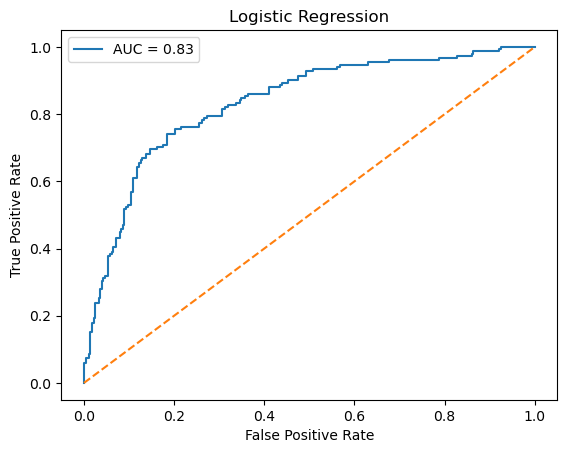

In [135]:
from sklearn.metrics import roc_curve, auc 
import matplotlib.pyplot as plt
y3_pred_lr= model_lr.predict_proba(x3_test)[:,1]# gives the probability of a sequence beign promoter bc we added 1 here 
fpr, tpr, _ = roc_curve(y_test, y3_pred_lr)# - is the part of thresholds , so if i need it i can write it , but for plotting i might not use thsis
roc_auc = auc(fpr, tpr)

#plot
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--") 
plt.xlabel("False Positive Rate") 
plt.ylabel("True Positive Rate") 
plt.title("Logistic Regression")
plt.legend() 
plt.show()

# training RF

In [127]:
from sklearn.ensemble import RandomForestClassifier
model_rf3 = RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced')
model_rf3.fit(x3_train, y_train)
y3_pred_rf = model_rf3.predict(x3_test)

#for kmer length 2
model_rf2 = RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced')
model_rf2.fit(x2_train, y_train)
y2_pred_rf = model_rf2.predict(x2_test)

#for kmer length 4
model_rf4 = RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced')
model_rf4.fit(x4_train, y_train)
y4_pred_rf = model_rf4.predict(x4_test)

# accurcay of rf

In [128]:
#2
test2_acc=accuracy_score(y_test, y2_pred_rf)
train2_acc= accuracy_score(y_train, model_rf2.predict(x2_train))
print('test and trainig accuracy for kmer 2:')
print('test2_acc:',test2_acc, '\ntrain2_acc:',train2_acc)
print('\nclassification report for kmer 2:')
print(classification_report(y_test, y2_pred_rf))
#3

test3_acc=accuracy_score(y_test, y3_pred_rf)
train3_acc= accuracy_score(y_train, model_rf3.predict(x3_train))
print('test and trainig accuracy for kmer 3:')
print('test3_acc:',test3_acc, '\ntrain3_acc:',train3_acc)# here train_acc>test_acc which is overfitting even when kmer length is small bc my dataset is really smallso model memorires instead of generalizing
print('\nclassification report for kmer 3:')
print(classification_report(y_test, y3_pred_rf))

#4
test4_acc=accuracy_score(y_test, y4_pred_rf)
train4_acc= accuracy_score(y_train, model_rf4.predict(x4_train))
print('test and trainig accuracy for kmer 4')
print('test4_acc:',test4_acc, '\ntrain4_acc:',train4_acc)
print('\nclassification report for kmer 4:')
print(classification_report(y_test, y4_pred_rf))

test and trainig accuracy for kmer 2:
test2_acc: 0.7715617715617715 
train2_acc: 1.0

classification report for kmer 2:
              precision    recall  f1-score   support

           0       0.82      0.83      0.82       278
           1       0.68      0.66      0.67       151

    accuracy                           0.77       429
   macro avg       0.75      0.75      0.75       429
weighted avg       0.77      0.77      0.77       429

test and trainig accuracy for kmer 3:
test3_acc: 0.7832167832167832 
train3_acc: 1.0

classification report for kmer 3:
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       278
           1       0.75      0.58      0.65       151

    accuracy                           0.78       429
   macro avg       0.77      0.74      0.75       429
weighted avg       0.78      0.78      0.78       429

test and trainig accuracy for kmer 4
test4_acc: 0.8065268065268065 
train4_acc: 1.0

classification report

# confusion matrix for rf

In [129]:
from sklearn.metrics import confusion_matrix
cm3= confusion_matrix(y_test, y3_pred_rf)
cm3_df=pd.DataFrame(cm3,
                    index=['actual -','actual +'],
                    columns=['predicted -','predicted +'])
print('confusion matrix for kmer 3:\n',cm3_df)

cm2= confusion_matrix(y_test, y2_pred_rf)
cm2_df=pd.DataFrame(cm2,
                    index=['actual -','actual +'],
                    columns=['predicted -','predicted +'])
print('confusion matrix for kmer 2:\n',cm2_df)
cm4= confusion_matrix(y_test, y4_pred_rf)
cm4_df=pd.DataFrame(cm4,
                    index=['actual -','actual +'],
                    columns=['predicted -','predicted +'])
print('confusion matrix for kmer 4:\n',cm4_df)

confusion matrix for kmer 3:
           predicted -  predicted +
actual -          248           30
actual +           63           88
confusion matrix for kmer 2:
           predicted -  predicted +
actual -          231           47
actual +           51          100
confusion matrix for kmer 4:
           predicted -  predicted +
actual -          259           19
actual +           64           87


# roc curve for rf

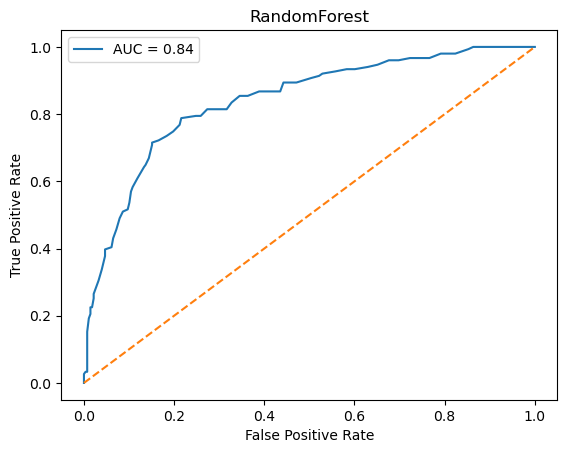

In [134]:
from sklearn.metrics import roc_curve, auc 
import matplotlib.pyplot as plt
y3_pred_lr= model_rf3.predict_proba(x3_test)[:,1]# gives the probability of a sequence beign promoter bc we added 1 here 
fpr, tpr, _ = roc_curve(y_test, y3_pred_lr) 
roc_auc = auc(fpr, tpr)

#plot
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--") 
plt.xlabel("False Positive Rate") 
plt.ylabel("True Positive Rate") 
plt.title('RandomForest')
plt.legend() 
plt.show()

In [131]:
# decision:
# overfitting: lr(no) , rf(yes)
#stable: lr(varied for kmer length) , rf( pretty close for all kmer)
#predicted 1 : lr_kmer_3( 100 out of 151) ,rf_kmer_3( 100 out of 151)
#auc: lr(0.83) ,rf(0.85)
#best accurcay:lr(0.8) , rf(0.80) 

# cross validation for rf and lr

In [132]:

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, recall_score
import numpy as np
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scorers = {
    "accuracy": "accuracy",
    "recall_promoter": make_scorer(recall_score, pos_label=1),
    "recall_nonpromoter": make_scorer(recall_score, pos_label=0)
}

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42,class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced')
}

feature_sets = {2: x2, 3: x3, 4: x4}

results = []

for k, X in feature_sets.items():
    for model_name, model in models.items():
        cv_results = cross_validate(model, X, y, cv=cv, scoring=scorers)
        results.append({
            "Model": model_name,
            "k": k,
            "Mean Accuracy": round(np.mean(cv_results["test_accuracy"]), 4),
            "Std Dev": round(np.std(cv_results["test_accuracy"]), 4),
            "Mean Recall (Promoter)": round(np.mean(cv_results["test_recall_promoter"]), 4),
            "Mean Recall (Non-Promoter)": round(np.mean(cv_results["test_recall_nonpromoter"]), 4)
        })
        print(f"✓ Done: {model_name} | k={k}")

results_df = pd.DataFrame(results).sort_values(["Model", "k"]).reset_index(drop=True)
results_df

✓ Done: Logistic Regression | k=2
✓ Done: Random Forest | k=2
✓ Done: Logistic Regression | k=3
✓ Done: Random Forest | k=3
✓ Done: Logistic Regression | k=4
✓ Done: Random Forest | k=4


,Model,k,Mean Accuracy,Std Dev,Mean Recall (Promoter),Mean Recall (Non-Promoter)
0,Logistic Regression,2,0.7468,0.0118,0.7543,0.7429
1,Logistic Regression,3,0.7567,0.0224,0.7638,0.7529
2,Logistic Regression,4,0.7674,0.0094,0.7597,0.7714
3,Random Forest,2,0.7581,0.0104,0.5547,0.8657
4,Random Forest,3,0.7721,0.0135,0.5627,0.8829
5,Random Forest,4,0.7669,0.0134,0.4912,0.9129


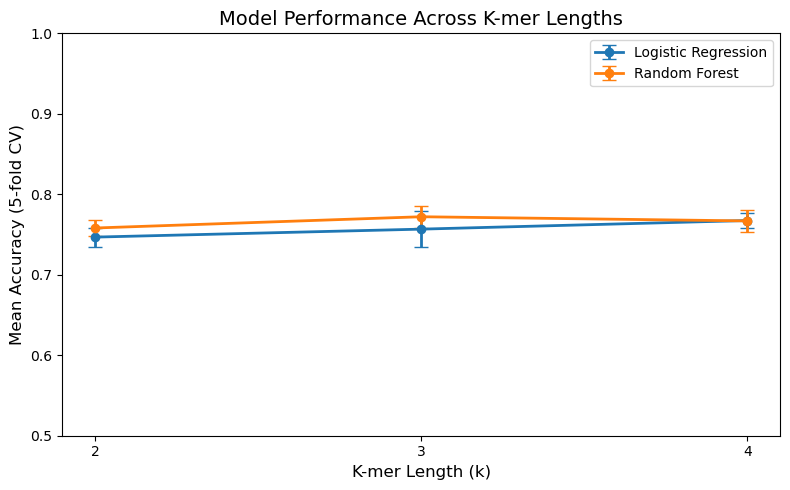

In [138]:
#plt 

fig, ax = plt.subplots(figsize=(8, 5))

for model_name in ["Logistic Regression", "Random Forest"]:
    subset = results_df[results_df["Model"] == model_name]
    ax.errorbar(
        subset["k"], subset["Mean Accuracy"], yerr=subset["Std Dev"],
        marker='o', label=model_name, capsize=5, linewidth=2
    )

ax.set_xlabel("K-mer Length (k)", fontsize=12)
ax.set_ylabel("Mean Accuracy (5-fold CV)", fontsize=12)
ax.set_title("Model Performance Across K-mer Lengths", fontsize=14)
ax.legend()
ax.set_xticks([2, 3, 4])
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.savefig("kmer_cv_comparison(2).png", dpi=150)
plt.show()